In [ ]:
from google.colab import files
uploaded = files.upload()


Saving packet1.pcapng to packet1.pcapng


In [ ]:
!apt-get update -y
!apt-get install -y tshark


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,891 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127

In [ ]:
PCAP_FILE = "packet1.pcapng"

!tshark -r "{PCAP_FILE}" \
  -Y "tcp.analysis.ack_rtt" \
  -T fields \
  -E header=y -E separator=, -E quote=d \
  -e frame.time_epoch \
  -e ip.src -e ip.dst \
  -e tcp.analysis.ack_rtt \
  > rtt_data_multi.csv

!head -n 10 rtt_data_multi.csv


Running as user "root" and group "root". This could be dangerous.
frame.time_epoch,ip.src,ip.dst,tcp.analysis.ack_rtt
"1770286637.201234535","10.10.166.232","3.233.158.114","0.000017855"
"1770286638.002332299","3.233.158.114","10.10.166.232","0.327249760"
"1770286638.002333211","3.233.158.114","10.10.166.232","0.327248281"
"1770286638.002905855","3.233.158.114","10.10.166.232","0.327573718"
"1770286638.359670336","3.233.158.114","10.10.166.232","0.357280050"
"1770286638.425081777","10.10.166.232","3.233.158.114","0.000017168"
"1770286639.325341785","3.233.158.114","10.10.166.232","0.356445553"
"1770286639.682340489","3.233.158.114","10.10.166.232","0.356955452"
"1770286639.706325436","10.10.166.232","3.233.158.114","0.000023107"


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("rtt_data_multi.csv")

# Convert RTT seconds → ms
df["ack_rtt_sec"] = pd.to_numeric(df["tcp.analysis.ack_rtt"], errors="coerce")
df = df.dropna(subset=["ack_rtt_sec"])

df["rtt_ms"] = df["ack_rtt_sec"] * 1000
df["oneway_ms"] = df["rtt_ms"] / 2

df.head()


,frame.time_epoch,ip.src,ip.dst,tcp.analysis.ack_rtt,ack_rtt_sec,rtt_ms,oneway_ms
0,1.770287e+09,10.10.166.232,3.233.158.114,0.000018,0.000018,0.017855,0.008927
1,1.770287e+09,3.233.158.114,10.10.166.232,0.327250,0.327250,327.249760,163.624880
2,1.770287e+09,3.233.158.114,10.10.166.232,0.327248,0.327248,327.248281,163.624140
3,1.770287e+09,3.233.158.114,10.10.166.232,0.327574,0.327574,327.573718,163.786859
4,1.770287e+09,3.233.158.114,10.10.166.232,0.357280,0.357280,357.280050,178.640025


In [ ]:
df["ip.dst"].value_counts()


,count
ip.dst,
10.10.166.232,61
35.244.180.134,18
3.220.16.13,15
34.144.254.29,13
3.233.158.114,7
172.64.148.235,7
35.241.24.90,4
35.244.233.98,3
142.250.4.188,1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("rtt_data_multi.csv")

# Convert RTT → ms
df["ack_rtt_sec"] = pd.to_numeric(df["tcp.analysis.ack_rtt"], errors="coerce")
df = df.dropna(subset=["ack_rtt_sec"])

df["rtt_ms"] = df["ack_rtt_sec"] * 1000
df["oneway_ms"] = df["rtt_ms"] / 2

df.head()


,frame.time_epoch,ip.src,ip.dst,tcp.analysis.ack_rtt,ack_rtt_sec,rtt_ms,oneway_ms
0,1.770287e+09,10.10.166.232,3.233.158.114,0.000018,0.000018,0.017855,0.008927
1,1.770287e+09,3.233.158.114,10.10.166.232,0.327250,0.327250,327.249760,163.624880
2,1.770287e+09,3.233.158.114,10.10.166.232,0.327248,0.327248,327.248281,163.624140
3,1.770287e+09,3.233.158.114,10.10.166.232,0.327574,0.327574,327.573718,163.786859
4,1.770287e+09,3.233.158.114,10.10.166.232,0.357280,0.357280,357.280050,178.640025


In [ ]:
distance_map = {
    # Local PU LAN
    "10.10.166.232": 0.2,

    # Google India edge (Chennai / Bangalore)
    "35.244.180.134": 200,
    "34.144.254.29": 200,
    "35.241.24.90": 200,
    "35.244.233.98": 200,
    "142.250.4.188": 180,
    "142.251.12.188": 180,

    # AWS (Mumbai / Singapore)
    "3.220.16.13": 400,
    "3.233.158.114": 400,

    # Cloudflare (India edge)
    "172.64.148.235": 150
}

df["distance_km"] = df["ip.dst"].astype(str).map(distance_map)
df = df.dropna(subset=["distance_km"])

df[["ip.dst","distance_km","oneway_ms"]].head(10)


,ip.dst,distance_km,oneway_ms
0,3.233.158.114,400.0,0.008927
1,10.10.166.232,0.2,163.624880
2,10.10.166.232,0.2,163.624140
3,10.10.166.232,0.2,163.786859
4,10.10.166.232,0.2,178.640025
5,3.233.158.114,400.0,0.008584
6,10.10.166.232,0.2,178.222777
7,10.10.166.232,0.2,178.477726
8,3.233.158.114,400.0,0.011554
9,172.64.148.235,150.0,0.011671


In [ ]:
X = df[["distance_km"]].values   # Independent variable
y = df["oneway_ms"].values       # Dependent variable


In [ ]:
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("Best-fit equation:")
print(f"One-way time (ms) = {model.coef_[0]:.6f} × Distance (km) + {model.intercept_:.6f}")
print("R² score:", r2_score(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))


Best-fit equation:
One-way time (ms) = -0.254713 × Distance (km) + 87.528972
R² score: 0.26827347169727844
RMSE: 61.94569632687703


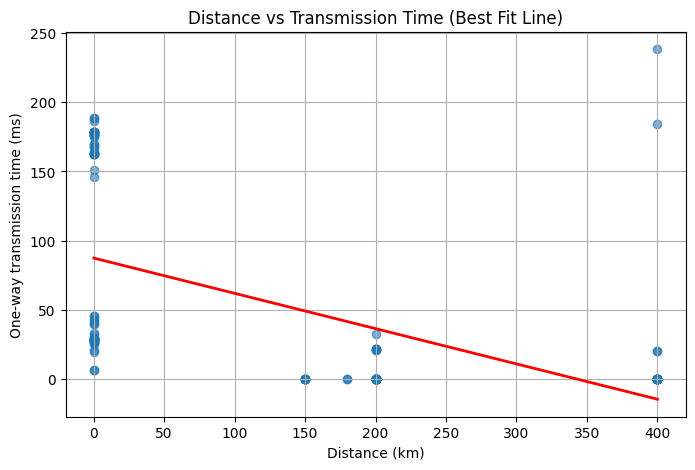

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.6)
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
plt.plot(x_line, model.predict(x_line), color="red", linewidth=2)

plt.xlabel("Distance (km)")
plt.ylabel("One-way transmission time (ms)")
plt.title("Distance vs Transmission Time (Best Fit Line)")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

# Remove local/private destinations
df = df[~df["ip.dst"].astype(str).str.startswith(("10.", "172.16.", "172.17.", "192.168."))].copy()

# Prefix-based distance mapping (more robust than exact IP matching)
prefix_distance_km = {
    # Google (often)
    "142.250.": 180,
    "142.251.": 180,
    "172.217.": 180,
    "35.": 200,          # many Google cloud IPs start with 35.*
    "34.": 200,          # Google cloud often 34.*

    # Cloudflare
    "172.64.": 150,
    "104.16.": 150,
    "104.17.": 150,

    # AWS (example ranges you observed)
    "3.220.": 400,
    "3.233.": 400,

    # GitHub can vary; keep generic if needed
    "20.205.": 400,
}

def distance_from_prefix(ip: str):
    ip = str(ip)
    for pfx, dist in prefix_distance_km.items():
        if ip.startswith(pfx):
            return dist
    return np.nan

df["distance_km"] = df["ip.dst"].astype(str).apply(distance_from_prefix)
df = df.dropna(subset=["distance_km"]).copy()

df[["ip.dst","distance_km","oneway_ms"]].head(10)


,ip.dst,distance_km,oneway_ms
0,3.233.158.114,400,0.008927
5,3.233.158.114,400,0.008584
8,3.233.158.114,400,0.011554
9,172.64.148.235,150,0.011671
17,3.233.158.114,400,0.016494
18,172.64.148.235,150,0.018841
20,142.251.12.188,180,0.239667
22,142.250.4.188,180,0.227560
25,34.144.254.29,200,0.025097
26,34.144.254.29,200,0.022482


In [ ]:
grp = df.groupby("distance_km", as_index=False)["oneway_ms"].mean()

X = grp[["distance_km"]].values
y = grp["oneway_ms"].values

model = LinearRegression().fit(X, y)

print(f"One-way time (ms) = {model.coef_[0]:.6f} * Distance(km) + {model.intercept_:.6f}")


One-way time (ms) = 0.087181 * Distance(km) + -13.847791


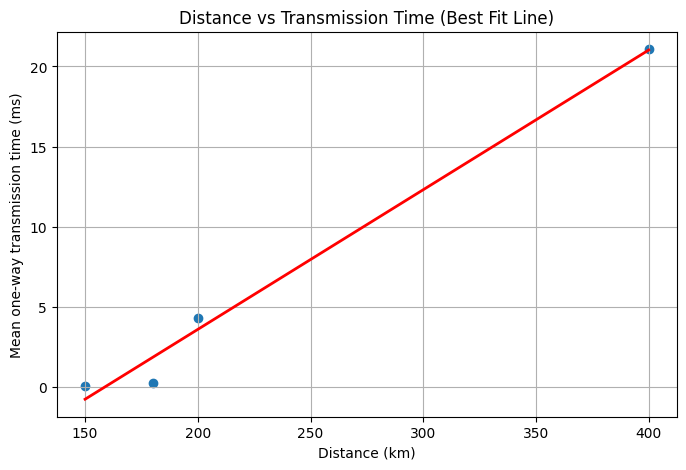

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(grp["distance_km"], grp["oneway_ms"])
x_line = np.linspace(grp["distance_km"].min(), grp["distance_km"].max(), 100)
plt.plot(x_line, model.predict(x_line.reshape(-1,1)), color="red", linewidth=2)
plt.xlabel("Distance (km)")
plt.ylabel("Mean one-way transmission time (ms)")
plt.title("Distance vs Transmission Time (Best Fit Line)")
plt.grid(True)
plt.show()
